In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score, r2_score
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torchvision.datasets
import torchvision.transforms as transforms
from torch.utils.data import WeightedRandomSampler
import random
import glob
from scipy.ndimage import gaussian_filter, zoom

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# @title
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False  ##uses the inbuilt cudnn auto-tuner to find the fastest convolution algorithms. -
    torch.backends.cudnn.enabled = False

    return True

device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")

Cuda installed! Running on GPU!


In [3]:
import sys
sys.path.append('/content/drive/MyDrive/IRP/scripts')

from CentreNetStrided import SCDCentreNet, CN_train, CenterNetLoss, build_centernet_targets, centroid_heatmap_metrics, CentreNetDataset
from SegNet import SegNet, CombinedLoss, SN_train, SegNetDataset
from ModelCompare import compare
from plot_predictions import visualise

In [4]:
models = {'Segmentation': {'model': SegNet, 'loss': CombinedLoss(), 'train_fn': SN_train, 'dataset': SegNetDataset},
          'CentreNet': {'model': SCDCentreNet, 'loss': CenterNetLoss(), 'train_fn': CN_train, 'dataset': CentreNetDataset}}
          #'HausdoorfSeg': {'model': HDSegNet, 'loss': HDLoss(), 'train_fn': HD_train, 'dataset': SegNetDataset}}

In [5]:
paths = glob.glob('/content/drive/MyDrive/IRP/SNIPApproved/*/*.npz')

In [6]:
cv_results, best_models, loaders = compare(models, epochs=75, paths=paths, cv=False)

Model: Segmentation 
Found 193 tiles (0 partial, 0 missing bands skipped)
Train: 155 | Val: 38
Best checkpoint saved (iou 0.1431)
Epoch   1/75 | train 0.7676 | val 0.6733 | acc 94.93% | iou 0.1431 | P 0.3932 | R 0.1837 | F1 0.2504 | Obj_P 0.1563 | Obj_R 0.7434 | Obj_F1 0.2583 | 
Best checkpoint saved (iou 0.1780)
Epoch   2/75 | train 0.6522 | val 0.6139 | acc 95.11% | iou 0.1780 | P 0.4414 | R 0.2297 | F1 0.3022 | Obj_P 0.2048 | Obj_R 0.7829 | Obj_F1 0.3247 | 
Best checkpoint saved (iou 0.3299)
Epoch   3/75 | train 0.6017 | val 0.5301 | acc 95.30% | iou 0.3299 | P 0.4909 | R 0.5014 | F1 0.4961 | Obj_P 0.2601 | Obj_R 0.8487 | Obj_F1 0.3981 | 
Best checkpoint saved (iou 0.3896)
Epoch   4/75 | train 0.5401 | val 0.5104 | acc 95.61% | iou 0.3896 | P 0.5202 | R 0.6081 | F1 0.5607 | Obj_P 0.3892 | Obj_R 0.8092 | Obj_F1 0.5256 | 
Epoch   5/75 | train 0.5104 | val 0.5003 | acc 96.07% | iou 0.3597 | P 0.5911 | R 0.4788 | F1 0.5291 | Obj_P 0.4566 | Obj_R 0.7961 | Obj_F1 0.5803 | 
Best checkpoint

In [7]:
import pickle

with open('/content/drive/MyDrive/IRP/results/seg_vs_centrenet_cv_full.pkl', 'wb') as f:
    pickle.dump(cv_results, f)

torch.save(best_models['Segmentation'], '/content/drive/MyDrive/IRP/models/seg_nocv_75.pkl')
torch.save(best_models['CentreNet'], '/content/drive/MyDrive/IRP/models/cn_nocv_75.pkl')

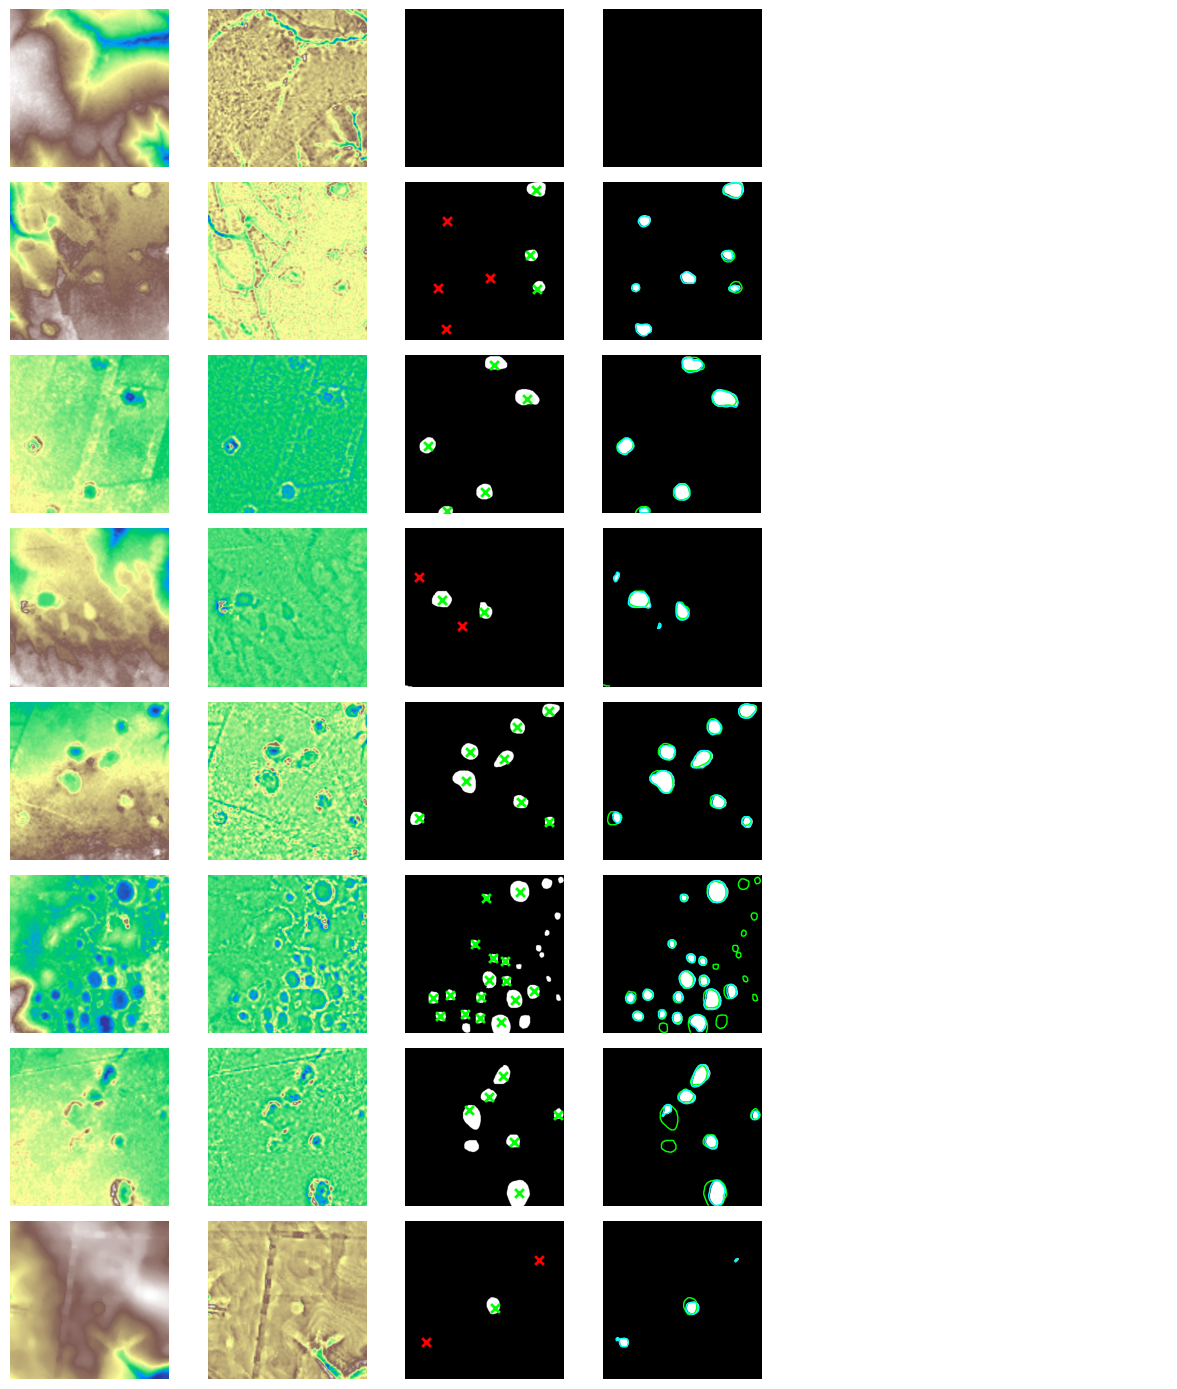

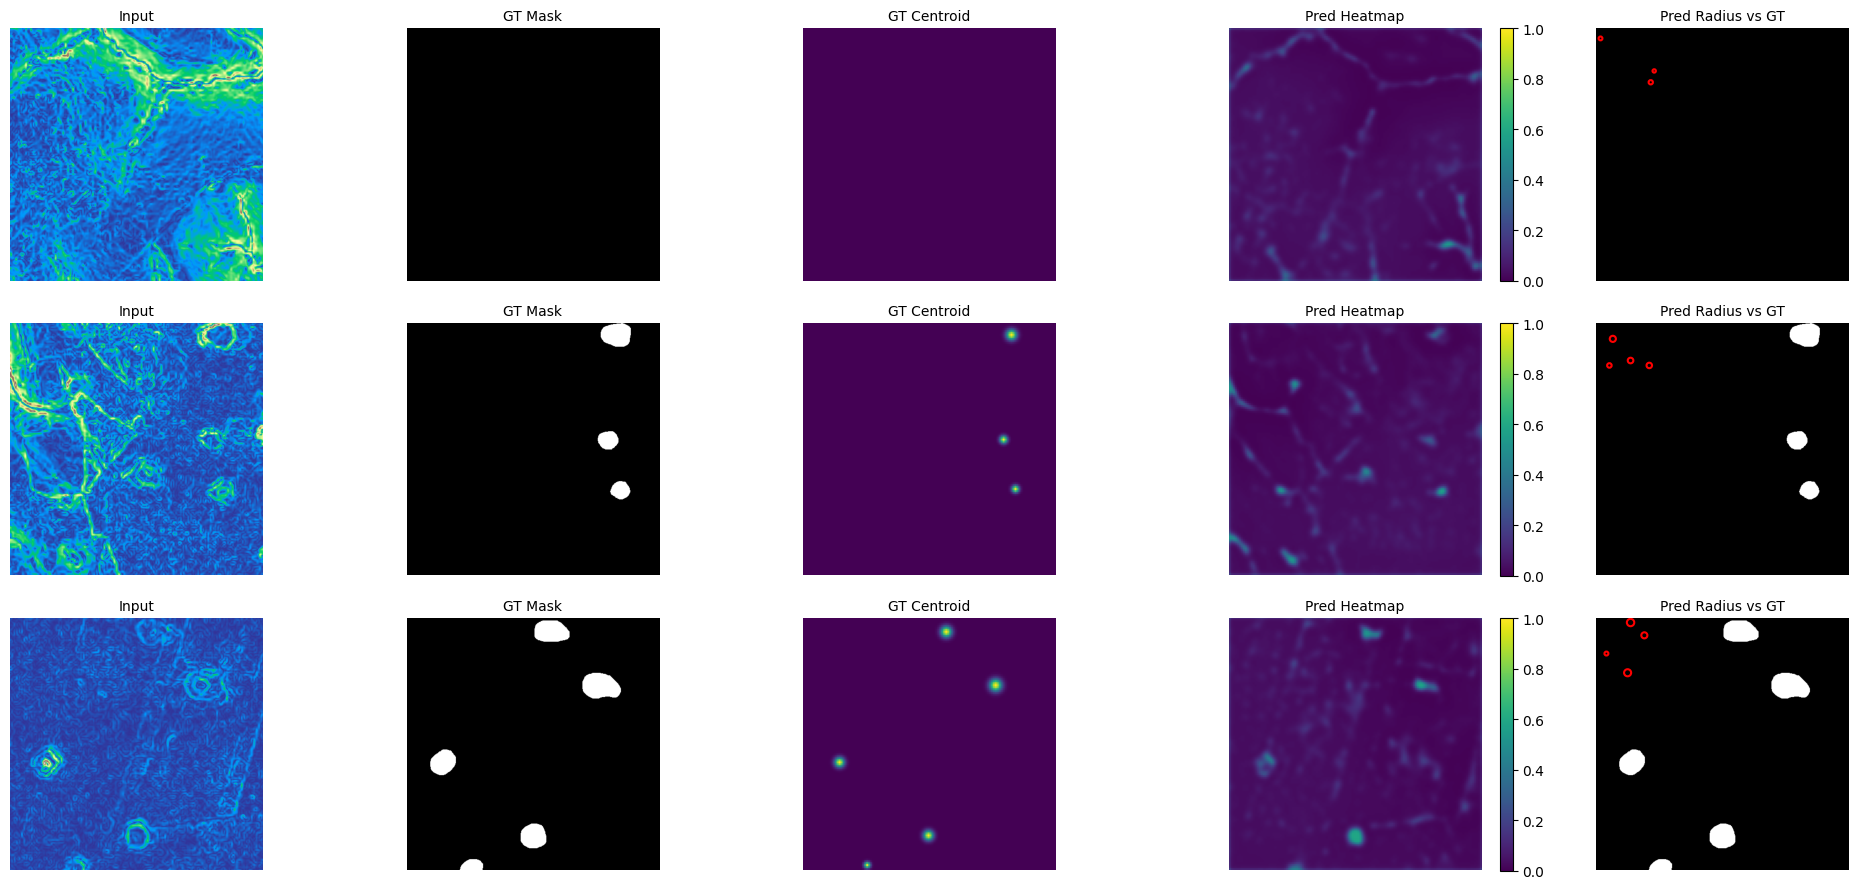

In [8]:
for model in models.keys():
  best_state = best_models[model]
  loader = loaders[model]


  visualise(model, best_state, loader, device)

In [9]:
from google.colab import runtime
runtime.unassign()